In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [2]:
df= pd.read_csv("telco_cleaned.csv")

In [3]:
df.head()

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TotalCharges,Churn,AvgMonthlySpend,TotalServices,CustomerValue,LongTerm,RevenuePerService,TenureGroup,SpendingLevel,Cluster
0,0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,...,29.85,No,14.925000,1,29.85,0,14.9250,1,1,0
1,1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,...,1889.50,No,53.985714,3,1936.30,1,14.2375,3,2,1
2,2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,...,108.15,Yes,36.050000,3,107.70,0,13.4625,1,2,1
3,3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,...,1840.75,No,40.016304,3,1903.50,1,10.5750,3,1,0
4,4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,...,151.65,Yes,50.550000,1,141.40,0,35.3500,1,2,1


In [4]:
df.shape
df.columns

Index(['Unnamed: 0', 'customerID', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'AvgMonthlySpend', 'TotalServices', 'CustomerValue',
       'LongTerm', 'RevenuePerService', 'TenureGroup', 'SpendingLevel',
       'Cluster'],
      dtype='object')

In [5]:
x = df.drop(columns=["customerID","Churn"])
y = df["Churn"]

# Encoding

In [7]:
target = LabelEncoder()
y = target.fit_transform(y)

In [8]:
cat_cols = (x.select_dtypes(include="object").columns)
encoder = ColumnTransformer(
[("cat",OneHotEncoder(drop="first",handle_unknown="ignore"),cat_cols)],
remainder="passthrough")
x = (encoder.fit_transform(x))

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=45,test_size=0.2)

In [10]:
print(
x_train.shape
)

print(
x_test.shape
)

(5634, 39)
(1409, 39)


# Feture scaling

In [12]:
scaler = StandardScaler()
x_train = (scaler.fit_transform(x_train))
x_test = (scaler.transform(x_test))

# Model Training - Decision Tree

In [14]:
from sklearn.tree import DecisionTreeClassifier

dt = (DecisionTreeClassifier(max_depth=6,random_state=42))
dt.fit(x_train,y_train)


DecisionTreeClassifier(max_depth=6, random_state=42)

In [15]:
pred_dt = (dt.predict(x_test))

# Model Training - Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = (RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42))
rf.fit(x_train,y_train)

RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42)

In [18]:
pred_rf = (rf.predict(x_test))

# Model Training - XGBoost

In [20]:
from xgboost import XGBClassifier

In [21]:
xgb = (XGBClassifier(n_estimators=300,learning_rate=0.05,max_depth=5,random_state=42))
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [22]:
pred_xgb = (xgb.predict(x_test))

In [23]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

In [24]:
print(accuracy_score(y_test,pred_dt))
print(accuracy_score(y_test,pred_rf))
print(accuracy_score(y_test,pred_rf))

0.8005677785663591
0.8133427963094393
0.8133427963094393


In [25]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [26]:
best_model = xgb

In [27]:
best_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [28]:
x_train_df = pd.DataFrame(x_train)

In [29]:
import shap

explainer = shap.Explainer(
    best_model.predict,
    x_train_df
)

In [30]:
shap_values = (
explainer.shap_values(
x_test
)
)

PermutationExplainer explainer: 1410it [00:59, 20.56it/s]                                                              


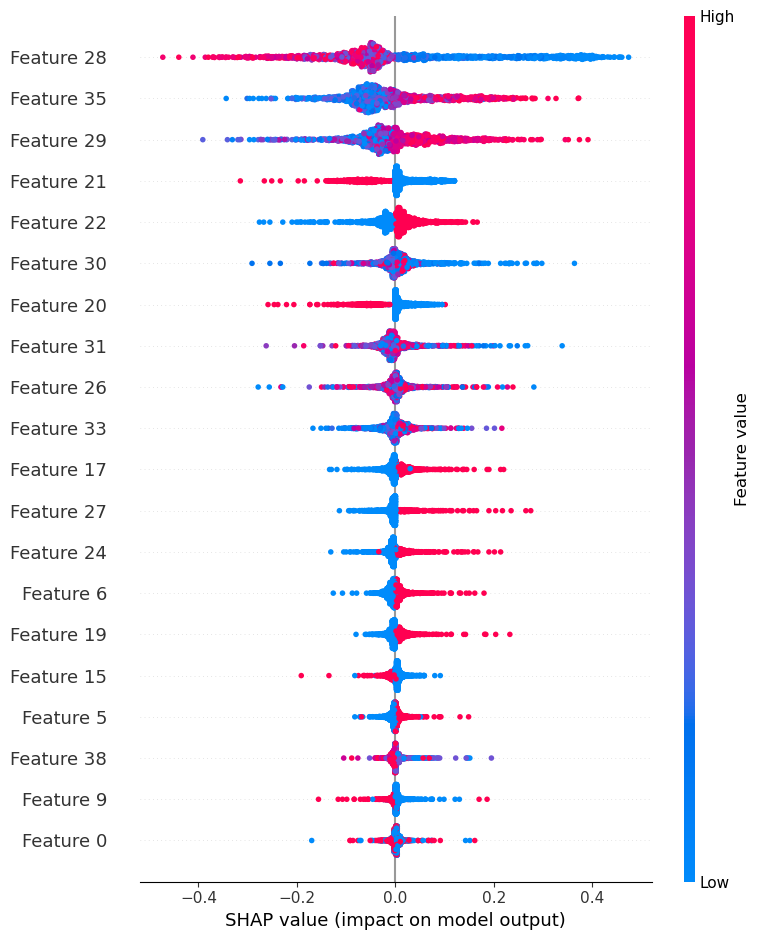

In [31]:
shap.summary_plot(
shap_values,
x_test
)

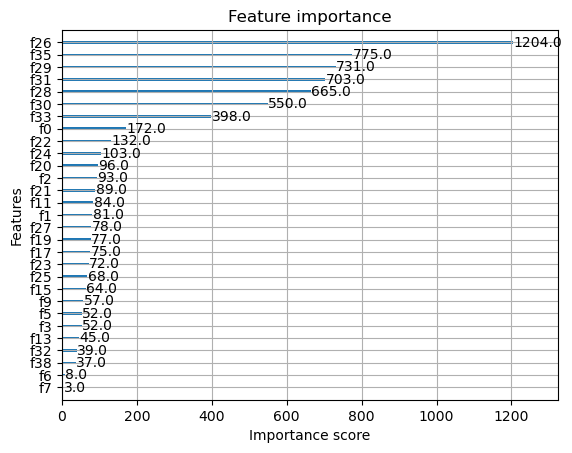

In [59]:
from xgboost import plot_importance
plot_importance(best_model)
plt.show()